In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
from scipy.stats import skew , kurtosis
import time
import tsplib95
import math

In [2]:
sys.path.append(os.path.abspath("../src"))
from populacao import Populacao
from pygenec.selecao.torneio import Torneio
from pygenec.cruzamento.edge_recombination import Edge_recombination
from pygenec.cruzamento.unponto import UmPonto

from pygenec.mutacao.inversion import Inversion
from pygenec.mutacao.swap import Swap

from pygenec.busca_local.opt_2 import Opt_2

from evolucao import Evolucao
from evolucao_tsp_classico import Evolucao_classica

from funcoes import Criar_Gif, Imagens_para_gif,Ate_convergir, Melhor_rota, Numero_de_geracoes, Arredondar_cima

In [3]:
sys.path.append(os.path.abspath("../data"))
problema = tsplib95.load("..\data\TSPLIB\kroA100.tsp")
solucao = tsplib95.load("..\data\TSPLIB\kroA100.opt.tour")

<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\joaoa\AppData\Local\Temp\ipykernel_24424\1860184843.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  problema = tsplib95.load("..\data\TSPLIB\kroA100.tsp")
C:\Users\joaoa\AppData\Local\Temp\ipykernel_24424\1860184843.py:3: SyntaxWarning: "\d" is an invalid escape sequence.

In [4]:
coordenadas = problema.node_coords
rota = solucao.tours[0]
rota = np.asarray(rota)-1

In [5]:
def adjacencias (dicionario):
    dist = []
    for i in coordenadas:
        linhas = []
        for j in coordenadas:
            soma = ((dicionario[i][0]-dicionario[j][0])**2) + ((dicionario[i][1]-dicionario[j][1])**2)
            raiz = soma**(1/2)
            linhas.append(raiz)
        dist.append(linhas)
    
    return dist

def fun(individuo):
    f = 0
    n = len(individuo)
    for i in range(n-1):
        local1 = individuo[i]
        local2 = individuo[i+1]
        distancia = dist[local1][local2]
        f += distancia
    f+= dist[individuo[-1]][individuo[0]]
    return f

def avaliacao(populacao):
    tpm = []
    for ind in populacao:
        tpm.append(fun(ind))
    tpm = np.asarray(tpm)
    return tpm

In [6]:
dist = adjacencias(coordenadas)
df = pd.DataFrame.from_dict(coordenadas, orient="index", columns=["x", "y"])

In [7]:
cromossos_totais = len(coordenadas)
Tamanho_populacao = 3*(cromossos_totais)
geracao = Numero_de_geracoes(cromossos_totais)
Valor_otimizador = 0.10
pmut = 0.3

## Híbrido

In [8]:
Nome = "AG Híbrido"
tam = problema.name
Juncao = Nome +" " +tam

In [9]:
populacao = Populacao(avaliacao, cromossos_totais, Tamanho_populacao)
populacao.gerar_populacao()
populacao.avaliar()
selecao = Torneio(populacao)
cruzamento = Edge_recombination(Tamanho_populacao)
mutacao = Inversion(pmut)
otimizador = Opt_2(dist)
evolucao = Evolucao(populacao,selecao,
                    cruzamento,mutacao,
                    otimizador,
                    Valor_otimizador,
                    geracao)

evolucao.nsele = round(Tamanho_populacao/2)
evolucao.pcruz = 0.8

In [10]:
inicio = time.time()
for _ in range(geracao):
    ger, mini, melhor= evolucao.evoluir()
    print(f"Geração {ger:3d} | Melhor fitness: {mini:.2f} | Melhor rota: {melhor}")
fim = time.time()

Geração   1 | Melhor fitness: 137103.45 | Melhor rota: [78 71 16 40 67 12 36 13 23 74 37  0 27 18 30 99 82 21 14  9  8 91  3 79
 38  4 42 20 59 58 92 45 39 28 53 35 26 84  5 96 34 73 80  1 32 98 68 85
 19 64 25 88  6 66 93 15 31 22 33 11 94 72 61 51 95 81 17 90 29 54 87 52
 24 97  7 41 55 62 70 77 47 49 63 43 75 69  2 10 56 60 86 44 46 89 76 50
 57 83 48 65]
Geração   2 | Melhor fitness: 137103.45 | Melhor rota: [78 71 16 40 67 12 36 13 23 74 37  0 27 18 30 99 82 21 14  9  8 91  3 79
 38  4 42 20 59 58 92 45 39 28 53 35 26 84  5 96 34 73 80  1 32 98 68 85
 19 64 25 88  6 66 93 15 31 22 33 11 94 72 61 51 95 81 17 90 29 54 87 52
 24 97  7 41 55 62 70 77 47 49 63 43 75 69  2 10 56 60 86 44 46 89 76 50
 57 83 48 65]
Geração   3 | Melhor fitness: 137103.45 | Melhor rota: [78 71 16 40 67 12 36 13 23 74 37  0 27 18 30 99 82 21 14  9  8 91  3 79
 38  4 42 20 59 58 92 45 39 28 53 35 26 84  5 96 34 73 80  1 32 98 68 85
 19 64 25 88  6 66 93 15 31 22 33 11 94 72 61 51 95 81 17 90 29 54 87 52
 24 

In [11]:
evo = evolucao.historico["Melhor_fitness"].copy()
assimetria = skew(evo)
curtose = kurtosis(evo)
desvio_padrao = np.std(evo)
melhor_rota = evolucao.melhor_solucao
tempo_de_execucao = fim - inicio
Tempo_ate_convergir = Ate_convergir(evo)
Otimo_global = fun(rota)

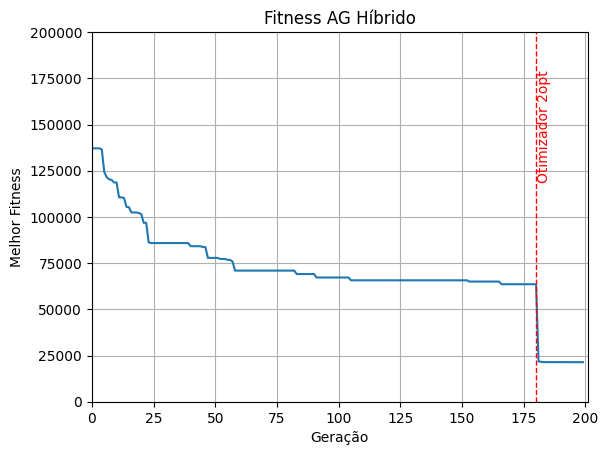

In [12]:
ROOT = os.path.abspath(os.path.join(".."))
caminhho = os.path.join(ROOT, "outputs", "graficos", f"{Juncao}.png")
linha_otmizador = geracao - (geracao*Valor_otimizador)
limite_y = Arredondar_cima(max(evo))

plt.plot(evolucao.historico["Melhor_fitness"])
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.ylim(0, limite_y)
plt.xlim(0, geracao + 1)
plt.axvline(x=linha_otmizador, color='r', linestyle='--', linewidth=1)
plt.text(linha_otmizador + 0.5, limite_y*0.6, 'Otimizador 2opt', rotation=90, color='red')
plt.title("Fitness " + Nome)
plt.grid(True)
plt.savefig(caminhho,dpi=300, bbox_inches="tight")
plt.show()

In [14]:
Melhor_rota(evolucao,df,Tamanho_populacao,Juncao,Nome,Alpha =0.03)

### Resultados

In [15]:
print("\n" + "="*40)
print(f"RESULTADOS - {Nome}")
print("="*40)

print(f"Assimetria:             {assimetria:.4f}")
print(f"Curtose:                {curtose:.4f}")
print(f"Desvio padrão:          {desvio_padrao:.4f}")
print(f"Tempo de execução:      {tempo_de_execucao:.2f} s")
print(f"Gerações até convergir: {Tempo_ate_convergir}")

print("-"*40)
print(f"Melhor fitness:         {min(evo):.4f}")
print(f"Melhor rota encontrada:\n{melhor_rota}")
print("-"*40)
print(f"Ótimo Global:           {(Otimo_global):.4f}")
print(f"Gap:                    {(min(evo) - Otimo_global):.4f}")

print("="*40)


RESULTADOS - AG Híbrido
Assimetria:             0.1665
Curtose:                1.8002
Desvio padrão:          22879.7247
Tempo de execução:      342.10 s
Gerações até convergir: 189
----------------------------------------
Melhor fitness:         21402.7593
Melhor rota encontrada:
[90 44 97 22 76 59 61 34 85 26 11 19 56  8  6 54 82 33 28 45 42  2 13 70
 40 99 47 51 77 95  4 36 32 75 12 94 81 38 29 84 67 72 49 43  1 53 39 63
 68 80 24 86 50 60 57 66 27 92 46  0 62  5 48 89 18 74 91  7 41 88 30 79
 55 96  3 64 25 65 69 21 93 15 87 52 78 17 23 37 98 35 83  9 71 20 73 58
 16 14 10 31]
----------------------------------------
Ótimo Global:           21285.4432
Gap:                    117.3161


## Clássico

In [16]:
Nome = "AG Clássico"
tam = problema.name
Juncao = Nome +" " +tam

In [17]:
populacao = Populacao(avaliacao, cromossos_totais, Tamanho_populacao)
populacao.gerar_populacao()
populacao.avaliar()
selecao= Torneio(populacao)
cruzamento = UmPonto(Tamanho_populacao)
mutacao = Swap(pmut)
evolucao = Evolucao_classica(populacao,selecao,
                    cruzamento,mutacao)

evolucao.nsele = round(Tamanho_populacao/2)
evolucao.pcruz = 0.8

In [18]:
inicio = time.time()
for _ in range(geracao):
    ger, mini, melhor= evolucao.evoluir()
    print(f"Geração {ger:3d} | Melhor fitness: {mini:.2f} | Melhor rota: {melhor}")
fim = time.time()

Geração   1 | Melhor fitness: 144795.97 | Melhor rota: [ 5 95 77 88 57 56 17 25 51  1 69  3 75 50  6 99 61 98 58 55 89 15 87 37
 27 21 90 94 12 49 14 16 54 36 97 72 96 70 47 82 38  4 40 59 35 41 85 29
 31  8 81 22 43 46 48 19 32 65 80 74 63 73 83 79  9 44 34 84 18 20  2 13
 26 53 67 28 45 86  7 91 11 92 33 52 66 62 30 78 23 76 39 93 42 71 64 60
 10 24 68  0]
Geração   2 | Melhor fitness: 142865.65 | Melhor rota: [84 34 42 79 92  5 33 95  8 57 72 88  3 44 51 77 56 17 25  1 69 75 50  6
 99 61 98 58 55 89 15 87 37 27 21 90 94 12 49 14 16 54 36 97 96 70 47 82
 38  4 40 59 35 41 85 29 31 81 22 43 46 48 19 32 65 80 74 63 73 83  9 18
 20  2 13 26 53 67 28 45 86  7 91 11 52 66 62 30 78 23 76 39 93 71 64 60
 10 24 68  0]
Geração   3 | Melhor fitness: 140509.59 | Melhor rota: [33 79 42 11 20 66 21 62 58 35 19 63 32 75 88  8 82 61 94 40 83  5 95 77
 57 56 17 25 51  1 69  3 50  6 99 98 55 89 15 87 37 27 90 12 49 14 16 54
 36 97 72 96 70 47 38  4 59 52 41 85 29 31 81 22 43 46 48 65 80 74 73  9
 44 

In [19]:
evo = evolucao.historico["Melhor_fitness"].copy()
assimetria = skew(evo)
curtose = kurtosis(evo)
desvio_padrao = np.std(evo)
melhor_rota = evolucao.melhor_solucao
tempo_de_execucao = fim - inicio
Tempo_ate_convergir = Ate_convergir(evo)
Otimo_global = fun(rota)

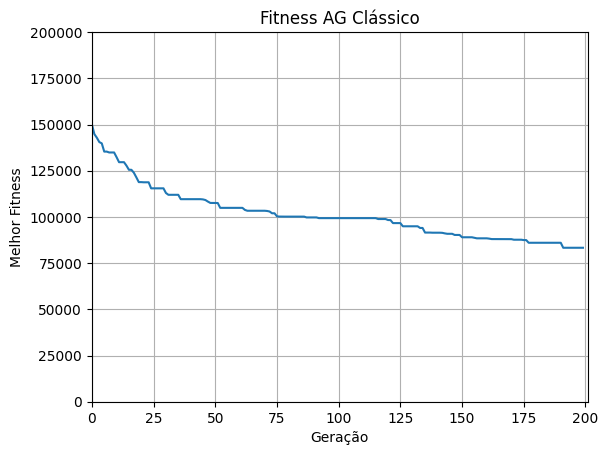

In [20]:
ROOT = os.path.abspath(os.path.join(".."))
caminhho = os.path.join(ROOT, "outputs", "graficos", f"{Juncao}.png")


plt.plot(evolucao.historico["Melhor_fitness"])
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.ylim(0, limite_y)
plt.xlim(0, geracao + 1)
plt.title("Fitness " + Nome)
plt.grid(True)
plt.savefig(caminhho,dpi=300, bbox_inches="tight")
plt.show()

In [21]:
Melhor_rota(evolucao,df,Tamanho_populacao,Juncao,Nome,Alpha =0.03)

### Resultados

In [22]:
print("\n" + "="*40)
print(f"RESULTADOS - {Nome}")
print("="*40)

print(f"Assimetria:             {assimetria:.4f}")
print(f"Curtose:                {curtose:.4f}")
print(f"Desvio padrão:          {desvio_padrao:.4f}")
print(f"Tempo de execução:      {tempo_de_execucao:.2f} s")
print(f"Gerações até convergir: {Tempo_ate_convergir}")

print("-"*40)
print(f"Melhor fitness:         {min(evo):.4f}")
print(f"Melhor rota encontrada:\n{melhor_rota}")
print("-"*40)
print(f"Ótimo Global:           {(Otimo_global):.4f}")
print(f"Gap:                    {(min(evo) - Otimo_global):.4f}")

print("="*40)


RESULTADOS - AG Clássico
Assimetria:             1.1761
Curtose:                1.2463
Desvio padrão:          13869.2890
Tempo de execução:      80.29 s
Gerações até convergir: 191
----------------------------------------
Melhor fitness:         83310.5343
Melhor rota encontrada:
[ 5 48 55 84 95 51 77  2 57 56 61 11 38 13 28 19  8 91 89 62 66 22 59 76
 16  0 41 69 17 98 37 25 64 87 78  3 92 63 27 58 14 20 31 44 97 81  1 49
 50  6 32 75 12 47 45 54 39 53 72 67 24 60 68 90  9 65 30 88 96 10 86  4
 43 80 52 83 15 71 42 40 70 85 34 93 74  7 21 23 18 79 29 99 33 36 94 82
 26 46 73 35]
----------------------------------------
Ótimo Global:           21285.4432
Gap:                    62025.0911
